# IDS NSL-KDD — Data Science in Cyber Final Project

Reproduction and critical evaluation of Arcos-Argudo et al. (2025) on the NSL-KDD intrusion detection benchmark.

Source paper: Arcos-Argudo et al. (2025), *Algorithms* 18, 749.

## Executive Summary

This notebook reproduces and critically evaluates Arcos-Argudo et al. (2025), who compare classical classifiers (Naïve Bayes, Logistic Regression, LDA) and a hybrid Autoencoder + Logistic Regression (AE+LR) pipeline for binary intrusion detection on NSL-KDD.

**Reproduction.** We ran the authors' replication notebook logic via `results/baseline_reproduction.csv` and independently rebuilt the pipeline from raw `KDDTrain+.txt` / `KDDTest+.txt` in `src/`. All eight author model/regime combinations match paper Tables 4–5 within ±0.02 (most exact). Our train-only preprocessing pipeline (106 features, correlated numerics dropped) diverges from the authors' bundled CSVs and joint one-hot encoding (119 features).

**Key results (our pipeline, no SMOTE).** LDA achieves the best F1 among paper models (0.752); Random Forest — added as an assignment extension — achieves the highest AUC (0.960). AE+LR underperforms LDA on both F1 (0.703) and AUC (0.856) in our setting, contradicting the paper's headline claim when preprocessing is strictly leakage-free. Naïve Bayes retains extreme precision (0.968) and minimal FAR (0.65%) but misses ~85% of attacks (recall 0.15).

**SMOTE.** Training-only SMOTE produces modest F1 gains (+0.003 LDA, +0.008 LR, +0.031 AE+LR) without resolving rare-attack failure: R2L family recall stays ~8% and U2R ~10% for the best models.

**Critical verdict on author claims (C1–C7).** SMOTE benefit (C2), LDA/LR competitiveness (C4), NB precision/recall trade-off (C5), and FAR necessity (C6) are **supported**. AE+LR superiority (C1) and byte-level reproducibility (C7) are **partially supported** — true in the author CSV pipeline, fragile otherwise. Leakage-free preprocessing (C3) is **rejected** for the author notebook (train+test concat before encoding) but **supported** for our implementation.

**Recommendation.** Use the paper as a reproducible classical-ML benchmark with good metric hygiene (FAR, fixed seeds), not as a deployment recipe. For similar IDS studies: audit encoding for leakage, report per-attack-family recall, and treat LDA/LR as mandatory baselines before investing in hybrid models.

Full claim matrix and methodology critique: `docs/critical_evaluation.md`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    NSL_KDD_COLUMNS,
    add_binary_label,
    attack_category,
    find_constant_columns,
    find_duplicate_feature_columns,
    load_nsl_kdd,
    summarize_dataset,
)

sns.set_theme(style='whitegrid')
FIG_DIR = PROJECT_ROOT / 'results' / 'figures' / 'eda'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)


Project root: C:\Users\User\Desktop\data science in cyber


## 1. Data loading and inspection

We use the official NSL-KDD split (KDDTrain+.txt / KDDTest+.txt). The difficulty score column is dropped because it is not used for modeling (consistent with the author replication notebook).





In [2]:
train_df, test_df = load_nsl_kdd()
train_df = add_binary_label(train_df)
test_df = add_binary_label(test_df)
train_df['attack_category'] = train_df['label'].map(attack_category)
test_df['attack_category'] = test_df['label'].map(attack_category)

print('Column names match NSL-KDD spec:', list(train_df.columns[:-1]) == [c for c in NSL_KDD_COLUMNS if c not in ('difficulty',)])
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Train memory (MB):', round(train_df.memory_usage(deep=True).sum() / 1e6, 2))
print('Dtypes:')
print(train_df.dtypes.value_counts())
display(summarize_dataset(train_df, 'train'))
display(summarize_dataset(test_df, 'test'))


Column names match NSL-KDD spec: False
Train shape: (125973, 44)
Test shape: (22544, 44)
Train memory (MB): 72.92
Dtypes:
int64      24
float64    15
object      5
Name: count, dtype: int64


,split,rows,columns,memory_mb,missing_total,duplicate_rows
0,train,125973,44,72.92,0,0


,split,rows,columns,memory_mb,missing_total,duplicate_rows
0,test,22544,44,13.06,0,0


### Missing values, constants, and duplicates





In [3]:
missing = train_df.isna().sum()
print('Missing values (train):', int(missing.sum()))
print('Constant columns:', find_constant_columns(train_df.drop(columns=['label','label_binary','attack_category'])))
print('Duplicate feature pairs:', find_duplicate_feature_columns(train_df))


Missing values (train): 0
Constant columns: ['num_outbound_cmds']


Duplicate feature pairs: []


### Temporal analysis

NSL-KDD records **connection-level features**, not packet timestamps. The duration field is connection length in seconds, not a global event time. Therefore we **cannot** perform true temporal drift analysis or time-based train/test validation. This is a dataset limitation we document for the report.





## 2. Exploratory data analysis





### 2.1 Label distribution (binary and attack families)

Real-world meaning: class balance affects metric choice — accuracy can be misleading when attacks are rare in deployment, but here the test set is **more attack-heavy** (~57%) than train (~47%), reflecting NSL-KDD's deliberate difficulty increase in KDDTest+.





,train,test
label_binary,,
0,67343,9711
1,58630,12833


attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

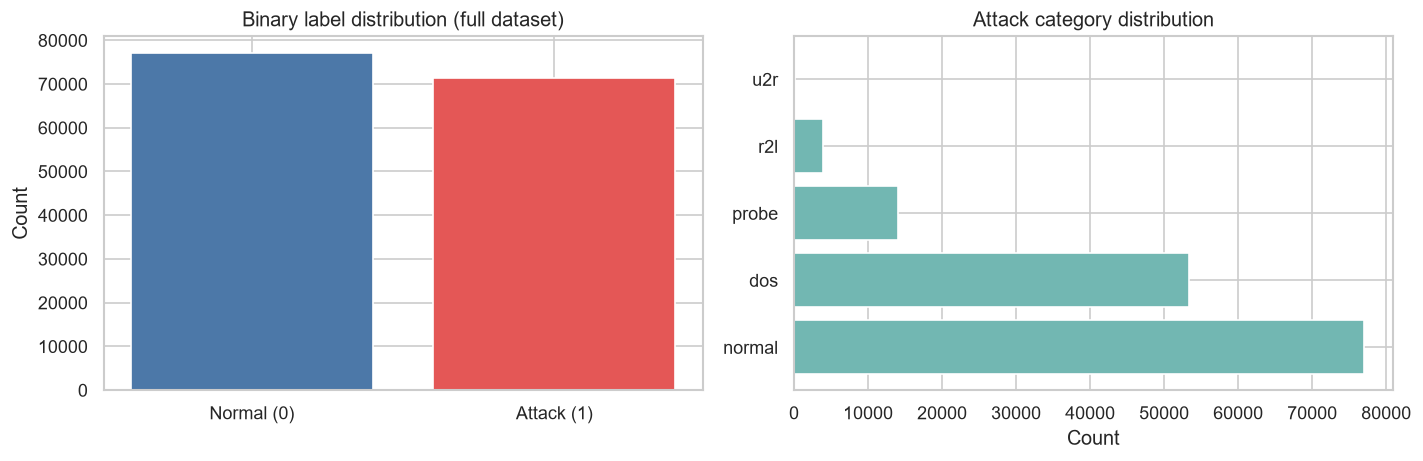

In [4]:
from IPython.display import Image, display as ipy_display

label_counts = pd.concat([
    train_df['label_binary'].value_counts().rename('train'),
    test_df['label_binary'].value_counts().rename('test'),
], axis=1)
display(label_counts)

subtype = train_df['attack_category'].value_counts()
display(subtype)

ipy_display(Image(filename=str(FIG_DIR / '01_label_distribution.png')))


### 2.2 Feature distributions and outliers

Network flow features such as src_bytes, dst_bytes, and count are heavy-tailed. We use the IQR rule on the **training set only** to flag potential outliers.





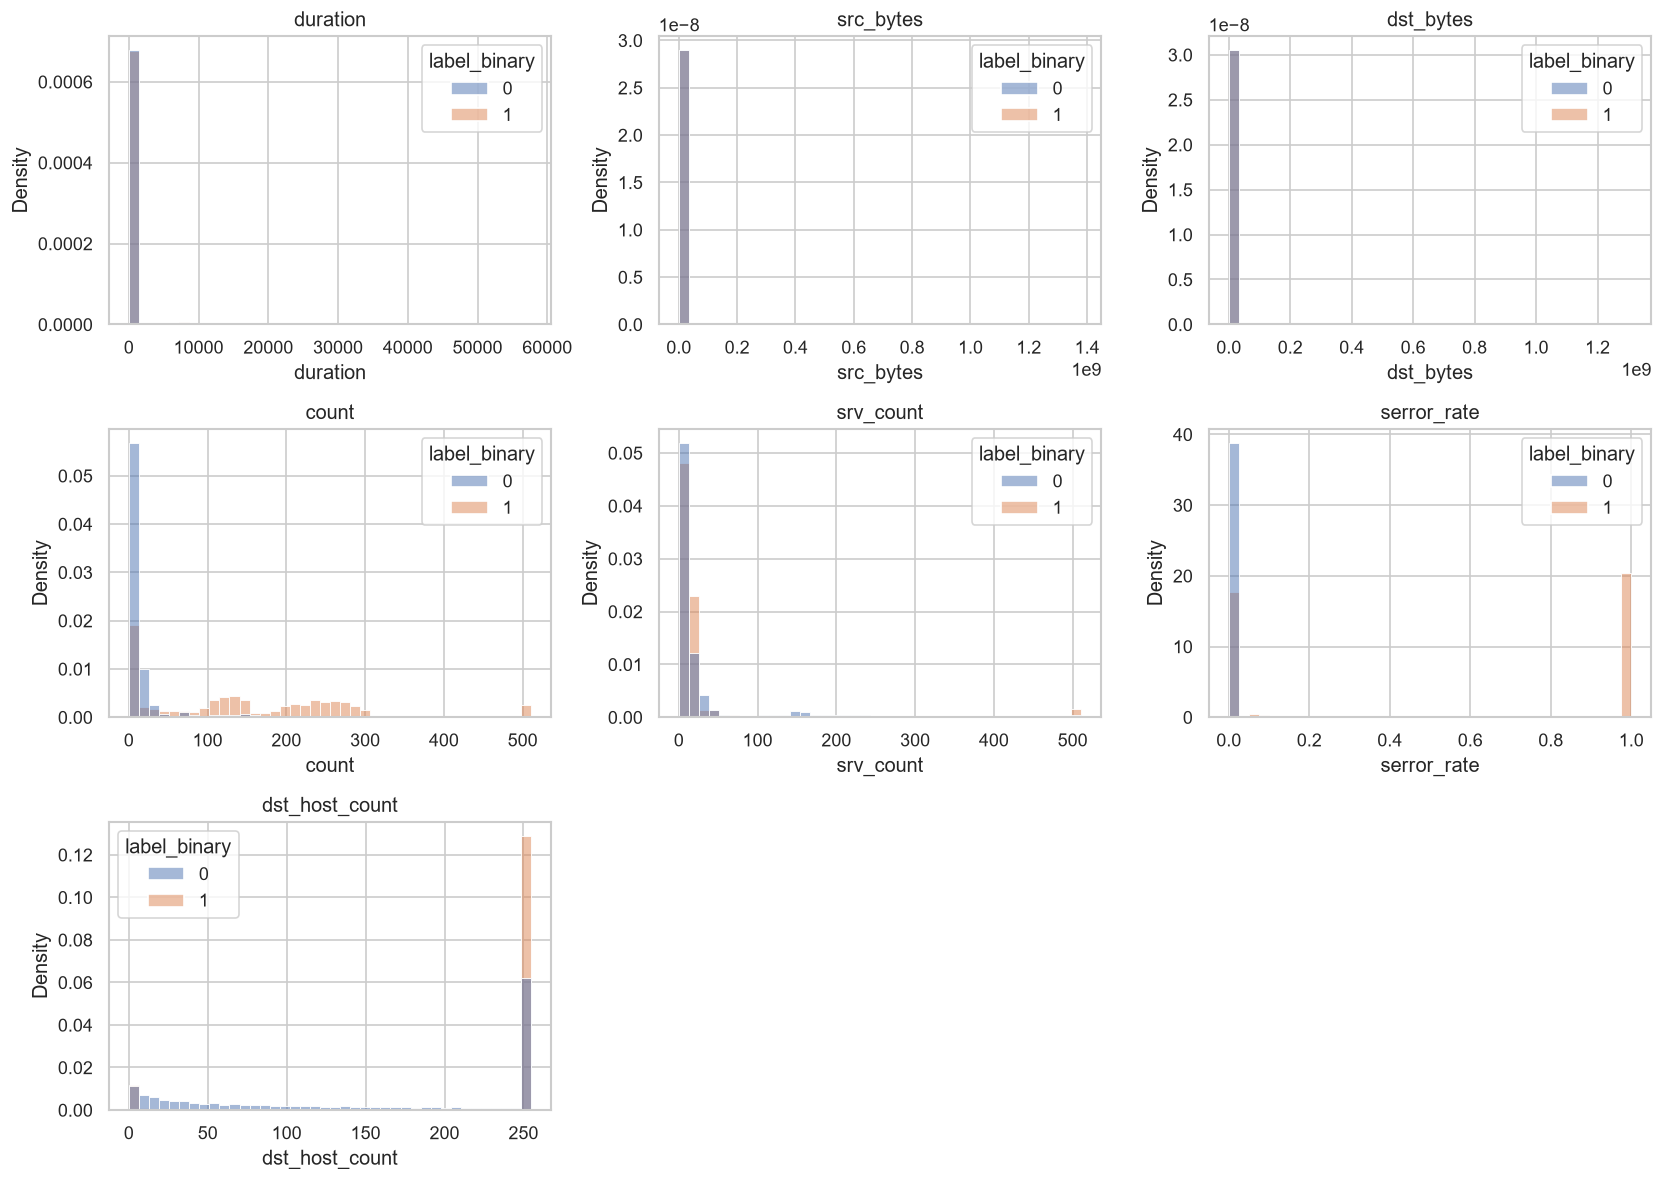

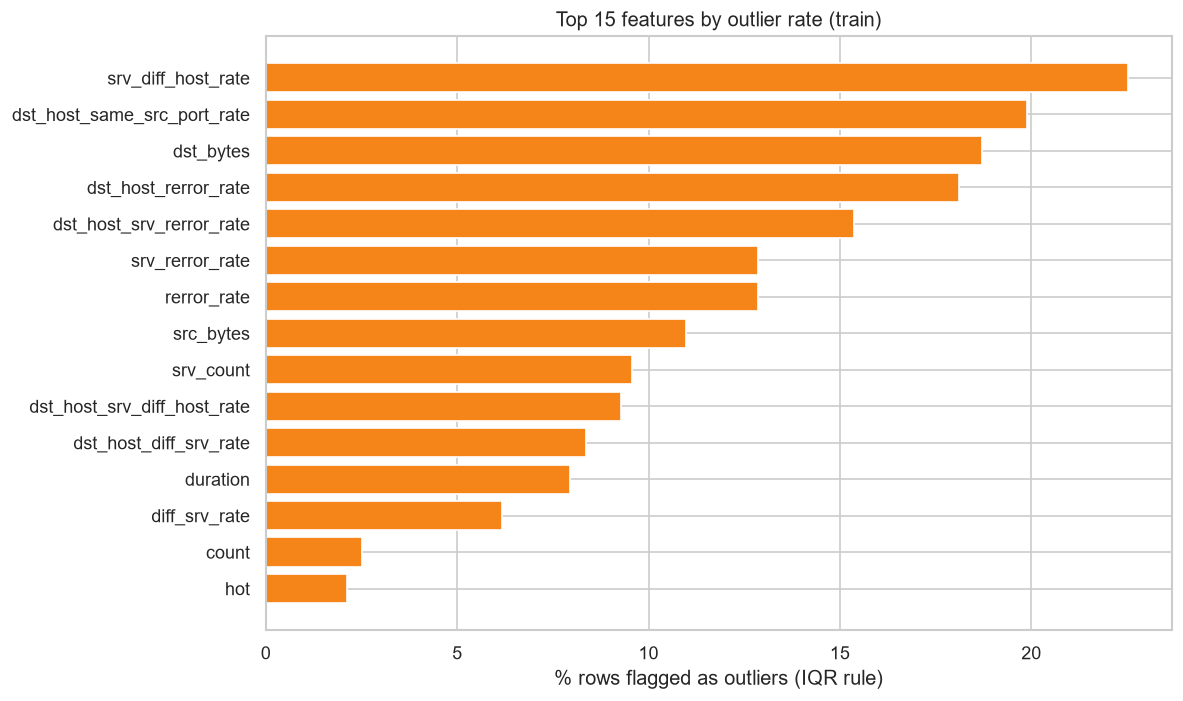

In [5]:
ipy_display(Image(filename=str(FIG_DIR / '03_numeric_distributions.png')))
ipy_display(Image(filename=str(FIG_DIR / '04_outlier_rates.png')))


### 2.3 Crosstab analysis (categorical vs attack label)

protocol_type, service, and lag encode connection metadata. High attack rates for specific services (e.g. HTTP-related) align with known attack patterns (DoS, probing).





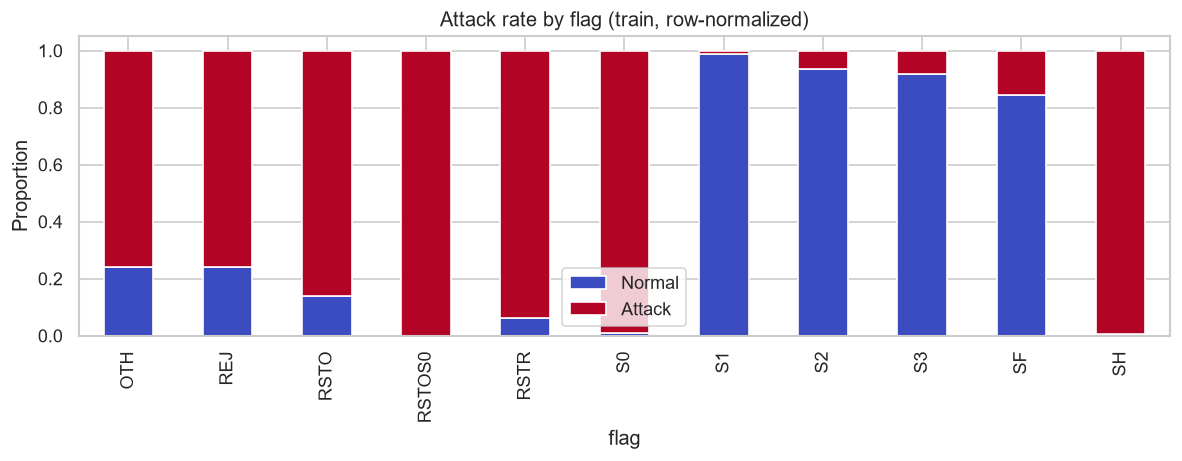

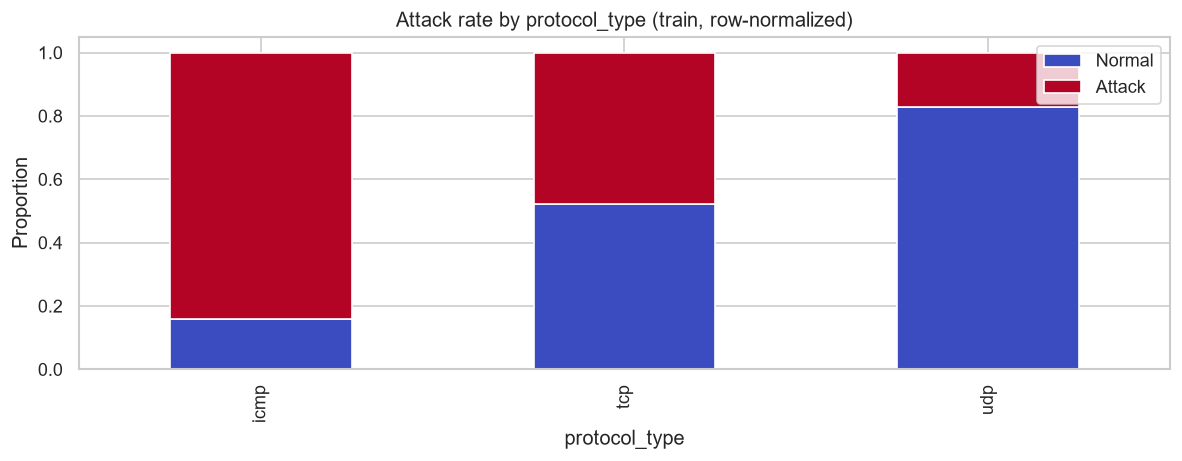

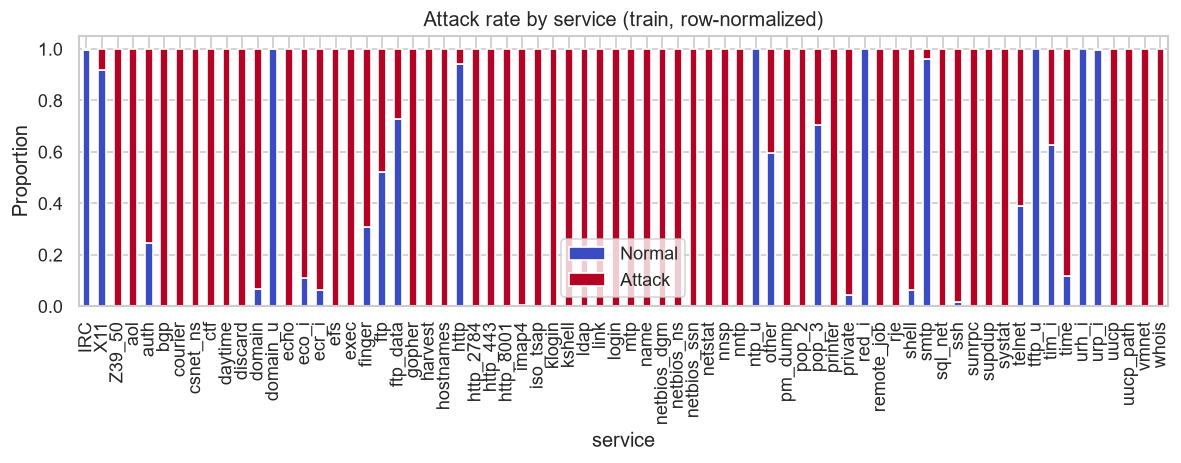

In [6]:
for fig in sorted(FIG_DIR.glob('05_crosstab_*.png')):
    ipy_display(Image(filename=str(fig)))


### 2.4 Correlation analysis

| Method | Use case | Assumptions |
|--------|----------|-------------|
| **Pearson** | Linear relationships between continuous numeric features | Sensitive to outliers; assumes approximate linearity |
| **Spearman** | Monotonic relationships; robust to outliers | Ranks-based; no normality required |
| **Kendall** | Small samples / ordinal consistency | Not shown here due to 34 numeric features — Pearson + Spearman suffice for redundancy detection |

For IDS tabular data, **Spearman** is often more appropriate for rate-based features (*_rate) that are bounded and skewed. **Pearson** helps identify linear redundancy (e.g. serror_rate vs srv_serror_rate).

Cybersecurity insight: highly correlated traffic statistics may leak overlapping information into models, inflating importance of a single underlying phenomenon (connection errors).





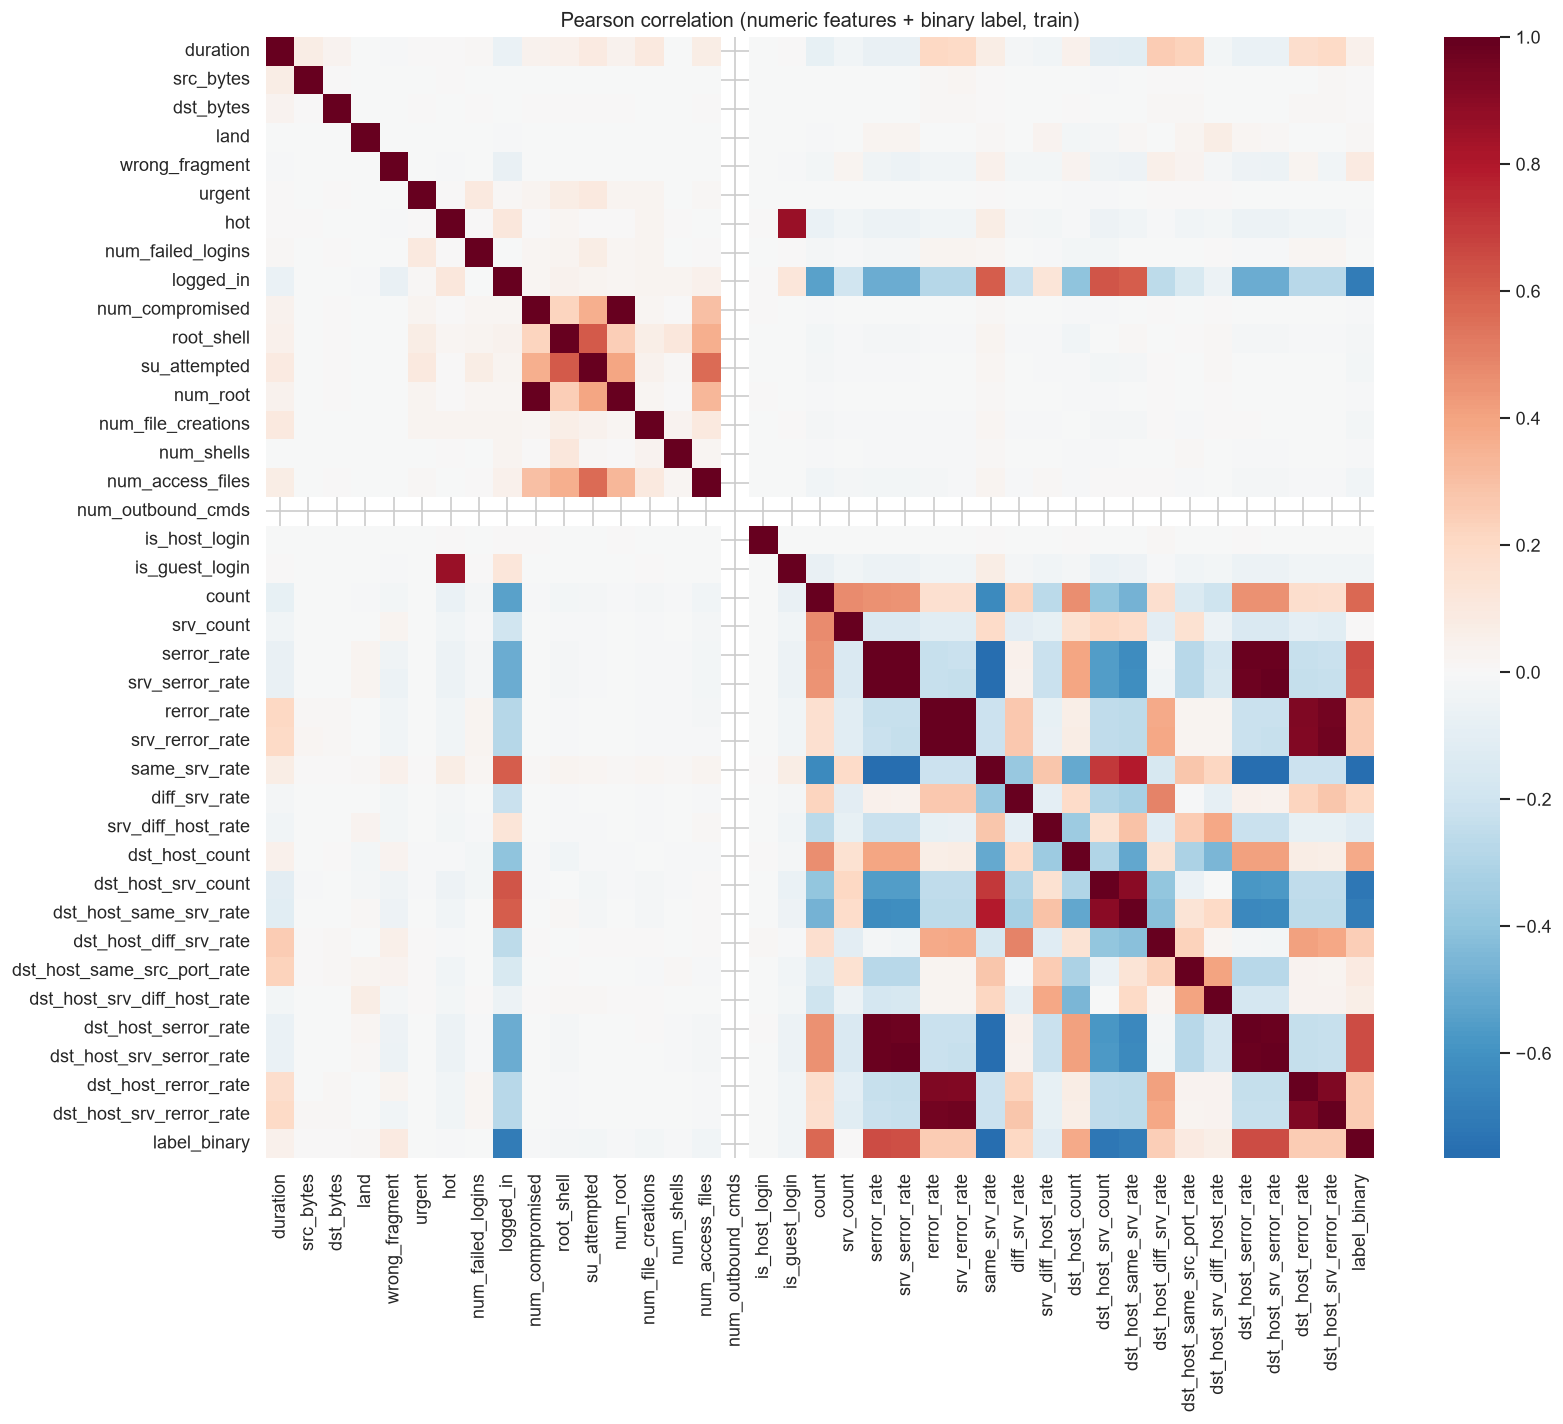

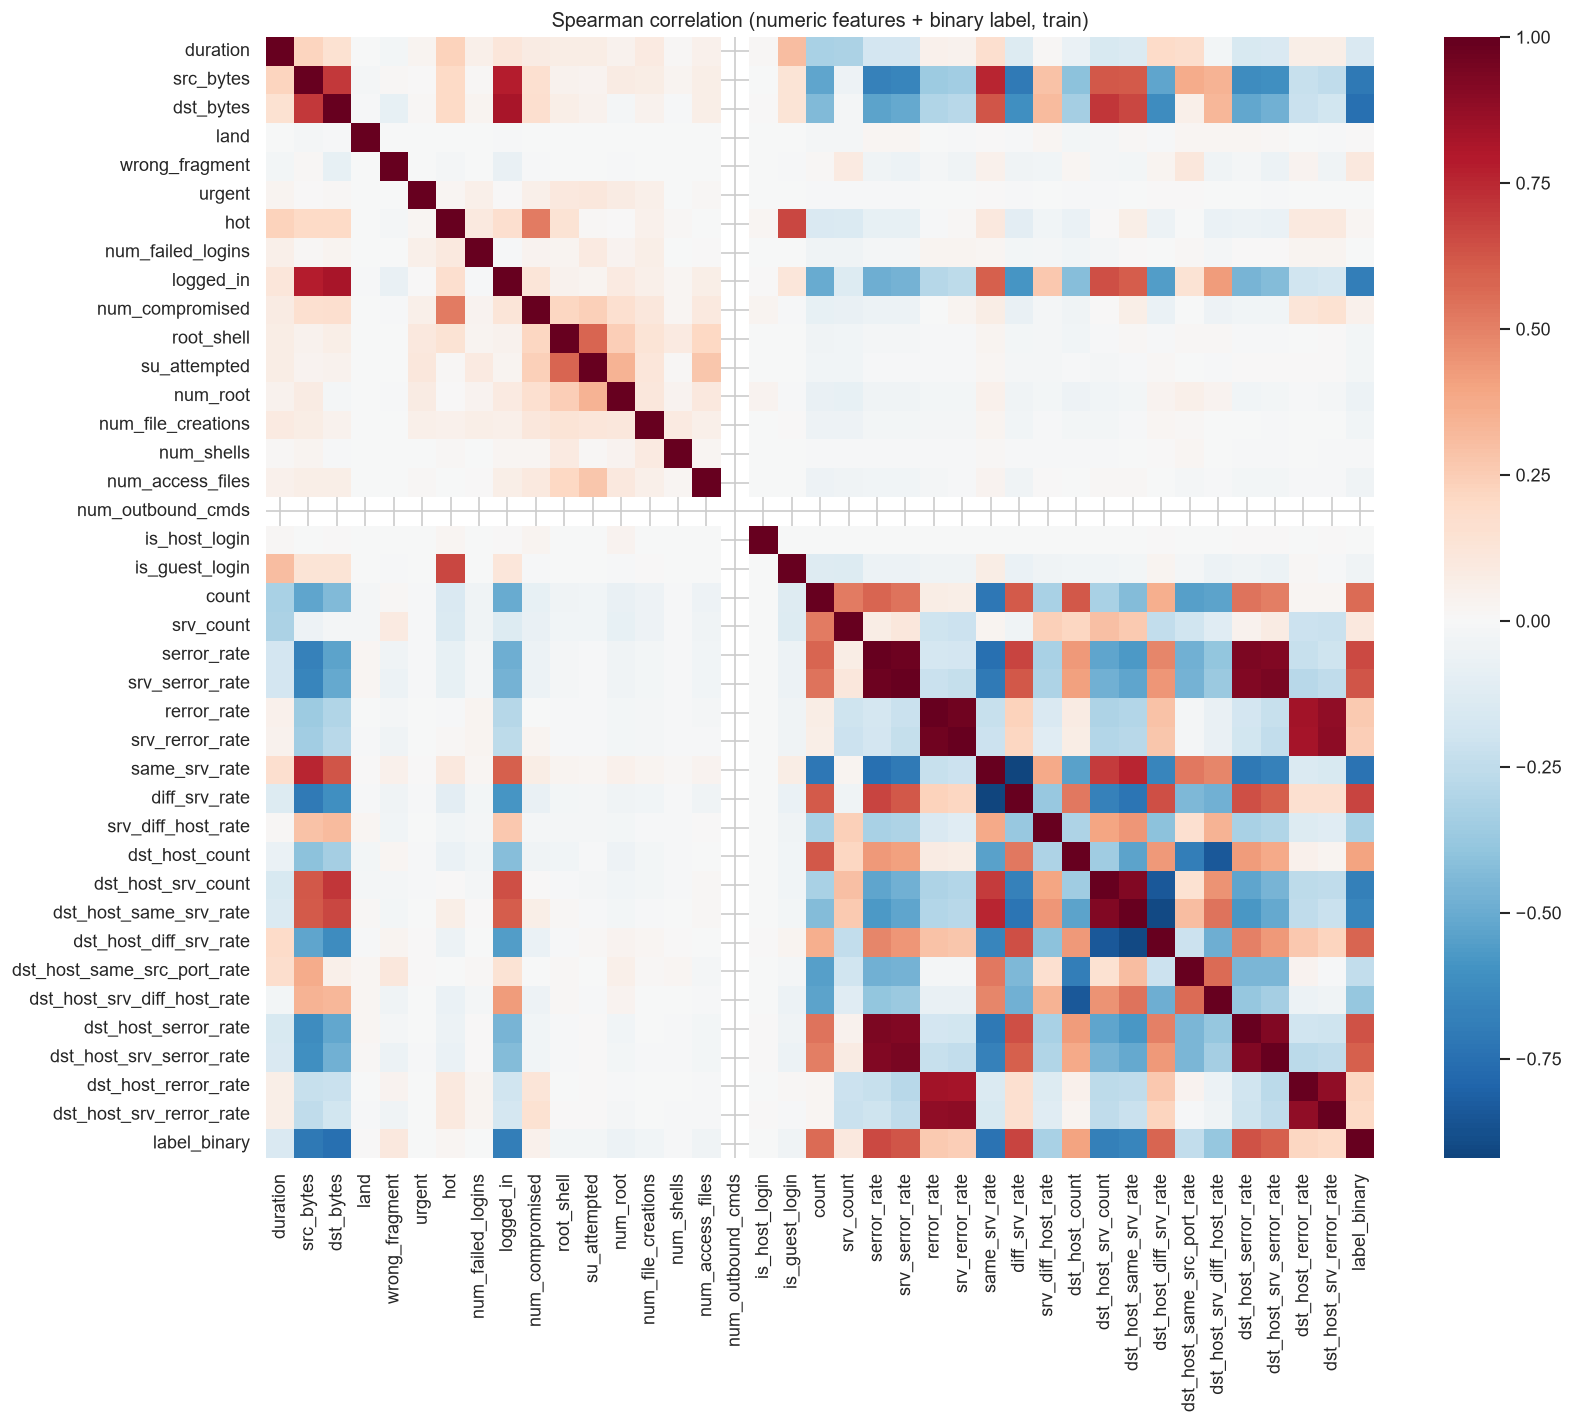

,feature_a,feature_b,pearson_r
0,num_compromised,num_root,0.9988
1,serror_rate,srv_serror_rate,0.9933
2,rerror_rate,srv_rerror_rate,0.9890
3,srv_serror_rate,dst_host_srv_serror_rate,0.9863
4,dst_host_serror_rate,dst_host_srv_serror_rate,0.9851
5,serror_rate,dst_host_srv_serror_rate,0.9811
6,serror_rate,dst_host_serror_rate,0.9794
7,srv_serror_rate,dst_host_serror_rate,0.9776
8,srv_rerror_rate,dst_host_srv_rerror_rate,0.9702
9,rerror_rate,dst_host_srv_rerror_rate,0.9644


In [7]:
ipy_display(Image(filename=str(FIG_DIR / '06_correlation_pearson.png')))
ipy_display(Image(filename=str(FIG_DIR / '07_correlation_spearman.png')))

high_corr = pd.read_csv(PROJECT_ROOT / 'results' / 'eda_high_correlation_pairs.csv')
display(high_corr.head(10))


### 2.5 Class imbalance

The authors address imbalance with **SMOTE on training data only** (author replication baseline). Our EDA shows:

- Train: ~53.5% normal / 46.5% attack
- Test: ~43.1% normal / 56.9% attack

Rare families (R2L, U2R) are collapsed when using binary labels — a limitation of the paper's binary evaluation.





,train,test
label_binary,,
0,0.534583,0.430758
1,0.465417,0.569242


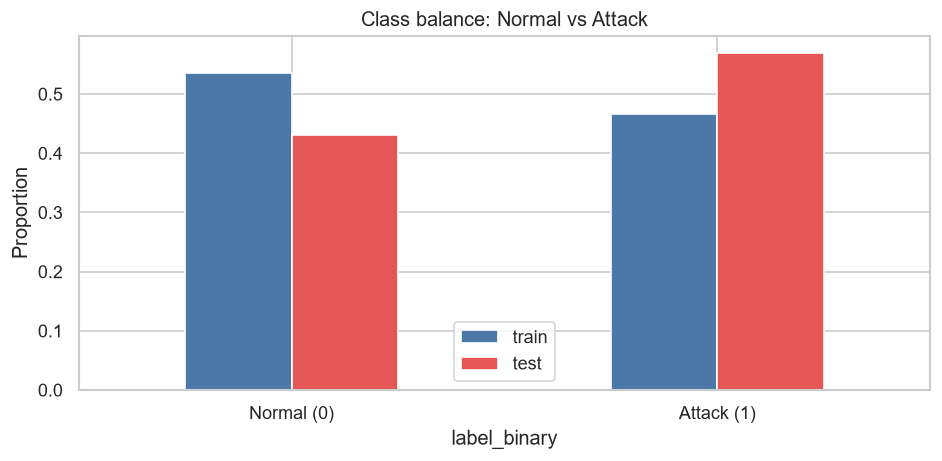

In [8]:
balance = pd.read_csv(PROJECT_ROOT / 'results' / 'eda_class_balance.csv', index_col=0)
display(balance)
ipy_display(Image(filename=str(FIG_DIR / '08_class_balance.png')))


## Exploratory analysis — key takeaways

- NSL-KDD loaded with canonical column names; no missing values.
- One constant feature: `num_outbound_cmds` (always 0 in train).
- No exact duplicate feature columns detected.
- Strong correlations among error-rate and host-based statistics suggest feature redundancy.
- No temporal axis — duration is per-connection, not a dataset timeline.
- Class distribution differs between train and test; SMOTE is applied only on train in the author pipeline.





## 3. Feature engineering

We build two preprocessing variants:

1. **`train_only`** (recommended): one-hot categories and min–max scaling are fit on **training data only**; test rows are aligned to the train schema.
2. **`author_concat`**: matches the replication notebook (`concat(train, test)` before `get_dummies`) for metric comparison.

Additional steps informed by EDA:

- Drop `num_outbound_cmds` (constant zero).
- Drop one feature from each highly correlated numeric pair (|r| ≥ 0.95).
- Optional **SMOTE** on the training matrix only when training models.




In [9]:
from src.preprocessing import (
    find_highly_correlated_numeric,
    leakage_checks,
    preprocess_nsl_kdd,
    split_features_and_labels,
)

FE_FIG_DIR = PROJECT_ROOT / 'results' / 'figures' / 'feature_engineering'
FE_FIG_DIR.mkdir(parents=True, exist_ok=True)

x_train_raw, x_test_raw, _, _ = split_features_and_labels(train_df, test_df)
corr_drop = find_highly_correlated_numeric(x_train_raw, threshold=0.95)
print('Features dropped for redundancy (|r|>=0.95):', corr_drop)
print('Leakage checks:', leakage_checks(x_train_raw, x_test_raw))


Features dropped for redundancy (|r|>=0.95): ['dst_host_srv_serror_rate', 'num_root', 'rerror_rate', 'serror_rate', 'srv_rerror_rate', 'srv_serror_rate']


Leakage checks: {'train_only_test_columns_subset_of_train': True, 'author_has_more_or_equal_columns_than_train_only': True, 'scaler_fit_on_train_only': True, 'smote_must_be_train_only': True}


### 3.1 Encoding and scaling

| Step | Method | Rationale (cybersecurity) |
|------|--------|---------------------------|
| Constant drop | Remove `num_outbound_cmds` | Zero variance — no discriminative signal for attacks |
| Redundancy drop | Pearson \|r\| ≥ 0.95 on train | Error-rate features measure overlapping connection anomalies |
| Categorical encoding | One-hot (`protocol_type`, `service`, `flag`) | Attack patterns differ by protocol/service (DoS on HTTP, probe on TCP) |
| Scaling | Min–max to [0, 1], fit on train | Keeps comparable weight across byte counts and rates |
| Imbalance | SMOTE (optional, train only) | Increases minority attack exposure without contaminating test distribution |




In [10]:
variants = {}
for enc in ['train_only', 'author_concat']:
    for smote in [False, True]:
        key = f'{enc}_smote={smote}'
        variants[key] = preprocess_nsl_kdd(
            train_df,
            test_df,
            encoding=enc,
            drop_constants=True,
            drop_correlated=True,
            apply_smote=smote,
        )

summary_rows = []
for name, data in variants.items():
    summary_rows.append({
        'variant': name,
        'encoding': data.encoding,
        'smote': data.smote_applied,
        'n_features': len(data.feature_names),
        'train_shape': data.X_train.shape,
        'test_shape': data.X_test.shape,
        'dropped': data.dropped_features,
    })

fe_summary = pd.DataFrame(summary_rows)
display(fe_summary[['variant', 'n_features', 'train_shape', 'test_shape']])

# Default pipeline for downstream modeling
default_prep = variants['train_only_smote=False']
print('Default feature matrix:', default_prep.X_train.shape, default_prep.X_test.shape)


,variant,n_features,train_shape,test_shape
0,train_only_smote=False,112,"(125973, 112)","(22544, 112)"
1,train_only_smote=True,112,"(134686, 112)","(22544, 112)"
2,author_concat_smote=False,112,"(125973, 112)","(22544, 112)"
3,author_concat_smote=True,112,"(134686, 112)","(22544, 112)"


Default feature matrix: (125973, 112) (22544, 112)


### 3.2 Author vs train-only encoding

The replication notebook encodes categories using **both** splits. That can introduce **schema leakage** (test-only categorical levels inform column space). Our `train_only` encoder prevents that; any unseen test category is ignored rather than expanding the feature space.




,variant,n_features
0,train_only_smote=False,112
2,author_concat_smote=False,112


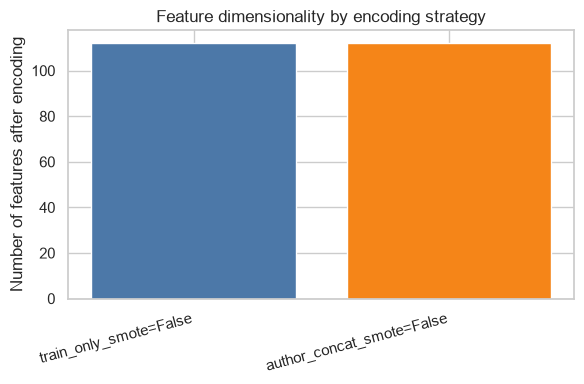

In [11]:
compare = fe_summary[fe_summary['smote'] == False][['variant', 'n_features']]
display(compare)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(compare['variant'], compare['n_features'], color=['#4c78a8', '#f58518'])
ax.set_ylabel('Number of features after encoding')
ax.set_title('Feature dimensionality by encoding strategy')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FE_FIG_DIR / 'encoding_feature_counts.png', dpi=120)
plt.show()


### 3.3 Feature engineering conclusions

- Dropping correlated error-rate and host statistics reduces redundancy without removing protocol/service indicators.
- **Train-only encoding** is methodologically safer than concat-encoding for held-out evaluation.
- SMOTE resamples **only** `X_train` (125,973 → balanced majority/minority) and never touches `X_test`.
- These choices will be compared against the published results in the modeling section.




## 4. Model training

We train five classifiers on the **train-only** preprocessing pipeline (`default_prep` without SMOTE, and a SMOTE-resampled training set):

| Model | Role |
|-------|------|
| Naïve Bayes (NB) | Paper baseline — fast generative model |
| Logistic Regression (LR) | Paper baseline — linear decision boundary |
| Linear Discriminant Analysis (LDA) | Paper baseline — class-separating projection |
| Random Forest (RF) | Assignment extension beyond the paper |
| Autoencoder + LR (AE+LR) | Paper hybrid — nonlinear embeddings + linear classifier |

Hyperparameters follow Arcos-Argudo et al. (2025) where applicable (`random_state=42`, LR `max_iter=1000`, AE 20 epochs). SMOTE is applied to **training data only** when enabled.



In [12]:
from src.models import (
    compare_to_baseline,
    save_comparison,
    save_training_log,
    train_all_models,
)

MODELS_DIR = PROJECT_ROOT / 'results' / 'models'
PREDICTIONS_DIR = PROJECT_ROOT / 'results' / 'predictions'
BASELINE_CSV = PROJECT_ROOT / 'results' / 'baseline_reproduction.csv'

training_results = []
baseline_checks = []

for smote in [False, True]:
    prep = variants[f'train_only_smote={smote}']
    print(f"\nTraining suite — SMOTE={smote}, features={prep.X_train.shape[1]}")
    batch = train_all_models(
        prep,
        save_dir=MODELS_DIR,
        predictions_dir=PREDICTIONS_DIR,
        include_rf=True,
    )
    training_results.extend(batch)
    baseline_checks.extend(compare_to_baseline(batch, BASELINE_CSV))

training_df = save_training_log(training_results, PROJECT_ROOT / 'results' / 'model_training.csv')
comparison_df = save_comparison(baseline_checks, PROJECT_ROOT / 'results' / 'baseline_comparison.csv')

display(training_df[['model', 'smote', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'far', 'train_seconds']])



Training suite — SMOTE=False, features=112



Training suite — SMOTE=True, features=112


,model,smote,accuracy,precision,recall,f1,auc,far,train_seconds
0,NB,False,0.5121,0.9679,0.1478,0.2565,0.7944,0.0065,0.389
1,LR,False,0.7340,0.9120,0.5897,0.7162,0.8431,0.0752,2.278
2,LDA,False,0.7618,0.9242,0.6334,0.7517,0.8601,0.0687,4.909
3,RF,False,0.7669,0.9666,0.6115,0.7491,0.9597,0.0279,10.323
4,AE+LR,False,0.7228,0.9011,0.5763,0.7030,0.8557,0.0836,70.103
5,NB,True,0.5121,0.9679,0.1478,0.2565,0.7936,0.0065,0.363
6,LR,True,0.7395,0.9129,0.5995,0.7238,0.8422,0.0756,2.872
7,LDA,True,0.7639,0.9235,0.6380,0.7547,0.8645,0.0698,4.865
8,RF,True,0.7766,0.9680,0.6284,0.7620,0.9565,0.0275,15.213
9,AE+LR,True,0.7463,0.9102,0.6150,0.7340,0.9078,0.0802,66.838


### 4.1 Training times and saved artifacts

Models are persisted under `results/models/`; test-set predictions (`y_pred`, `y_proba`) are saved to `results/predictions/` for downstream error analysis.



In [13]:
timing = training_df.pivot_table(
    index='model',
    columns='smote',
    values='train_seconds',
    aggfunc='first',
)
timing.columns = ['no_smote_sec', 'smote_sec']
display(timing.sort_index())

print('Saved models:', len(list(MODELS_DIR.glob('*'))), 'entries under', MODELS_DIR)


,no_smote_sec,smote_sec
model,,
AE+LR,70.103,66.838
LDA,4.909,4.865
LR,2.278,2.872
NB,0.389,0.363
RF,10.323,15.213


Saved models: 10 entries under C:\Users\User\Desktop\data science in cyber\results\models


### 4.2 Comparison with author replication baseline

The author baseline (`results/baseline_reproduction.csv`) uses **pre-cleaned CSVs** and **concat(train, test)** one-hot encoding. Our pipeline uses raw NSL-KDD, drops redundant features, and encodes categories on train only — so some divergence is expected and methodologically justified.



,model,smote,max_delta_vs_author,status,note
0,NB,False,0.1299,diverged,Expected: our pipeline uses train-only encodin...
1,LR,False,0.0182,close,Within tolerance of author baseline
2,LDA,False,0.0117,close,Within tolerance of author baseline
3,AE+LR,False,0.0632,diverged,Expected: our pipeline uses train-only encodin...
4,NB,True,0.1301,diverged,Expected: our pipeline uses train-only encodin...
5,LR,True,0.0182,close,Within tolerance of author baseline
6,LDA,True,0.0120,close,Within tolerance of author baseline
7,AE+LR,True,0.0320,diverged,Expected: our pipeline uses train-only encodin...


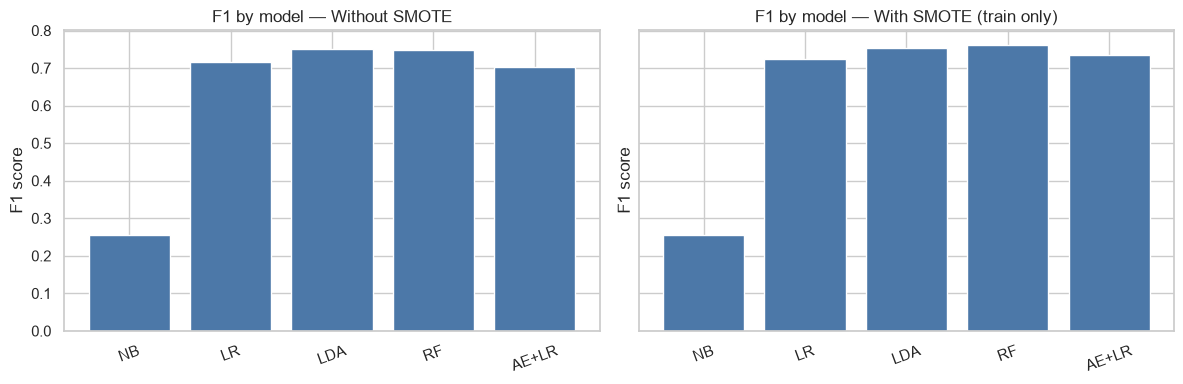

In [14]:
display(comparison_df[['model', 'smote', 'max_delta_vs_author', 'status', 'note']])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, smote_flag, title in zip(
    axes,
    [False, True],
    ['Without SMOTE', 'With SMOTE (train only)'],
):
    subset = training_df[training_df['smote'] == smote_flag]
    ax.bar(subset['model'], subset['f1'], color='#4c78a8')
    ax.set_title(f'F1 by model — {title}')
    ax.set_ylabel('F1 score')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'figures' / 'model_training_f1.png', dpi=120)
plt.show()


### 4.3 Modeling conclusions

- **RF** adds a nonlinear ensemble benchmark not evaluated in the paper; compare its recall/FAR trade-off in the evaluation section.
- **SMOTE** generally lifts recall on attacks at the cost of more false alarms — inspect per-model shifts above.
- Divergence from the author baseline reflects preprocessing differences (encoding + redundancy removal), not necessarily model bugs.
- Full metric interpretation, ROC curves, and attack-subtype error analysis follow in the next section.



## 5. Evaluation

We report the full metric suite on the held-out NSL-KDD test set. In a security operations center (SOC), **false positives** (benign traffic flagged as attack) create alert fatigue, while **false negatives** (missed attacks) create breach risk. We therefore emphasize precision, recall, FAR, and MCC alongside accuracy and AUC.


| Metric | Meaning | IDS relevance |
|--------|---------|---------------|
| **Accuracy** | Fraction of correct predictions | Misleading under imbalance — many attacks can be missed while accuracy stays high |
| **Precision** | TP / (TP + FP) | Analyst trust: high precision means fewer bogus tickets |
| **Recall** | TP / (TP + FN) | Coverage: low recall means stealthy or rare attacks slip through |
| **F1** | Harmonic mean of precision & recall | Single balance score for model comparison |
| **MCC** | Matthews correlation | Robust summary under class skew |
| **FAR** | FP / (FP + TN) | Operational false-alarm burden on normal traffic |
| **AUC** | Area under ROC | Threshold-independent ranking; does not fix a deployment threshold |


In [15]:
from src.evaluation import (
    METRIC_INTERPRETATIONS,
    build_experiment_metrics,
    load_all_predictions,
    plot_metric_comparison,
    plot_roc_curves,
    save_evaluation_artifacts,
    smote_delta_table,
)

EVAL_FIG_DIR = PROJECT_ROOT / 'results' / 'figures' / 'eval'
PREDICTIONS_DIR = PROJECT_ROOT / 'results' / 'predictions'
MODEL_LIST = ['NB', 'LR', 'LDA', 'RF', 'AE+LR']

experiment_metrics = build_experiment_metrics(PROJECT_ROOT / 'results' / 'model_training.csv')
predictions = load_all_predictions(PREDICTIONS_DIR, MODEL_LIST)

save_evaluation_artifacts(test_df, predictions, experiment_metrics, PROJECT_ROOT / 'results')

display(experiment_metrics[['model', 'smote', 'accuracy', 'precision', 'recall', 'f1', 'mcc', 'far', 'auc']])

print('Metric notes:')
for name, note in METRIC_INTERPRETATIONS.items():
    print(f'  {name}: {note}')


,model,smote,accuracy,precision,recall,f1,mcc,far,auc
0,AE+LR,False,0.7228,0.9011,0.5763,0.7030,0.5071,0.0836,0.8557
1,LDA,False,0.7618,0.9242,0.6334,0.7517,0.5733,0.0687,0.8601
2,LR,False,0.7340,0.9120,0.5897,0.7162,0.5283,0.0752,0.8431
3,NB,False,0.5121,0.9679,0.1478,0.2565,0.2484,0.0065,0.7944
4,RF,False,0.7669,0.9666,0.6115,0.7491,0.6021,0.0279,0.9597
5,AE+LR,True,0.7463,0.9102,0.6150,0.7340,0.5443,0.0802,0.9078
6,LDA,True,0.7639,0.9235,0.6380,0.7547,0.5760,0.0698,0.8645
7,LR,True,0.7395,0.9129,0.5995,0.7238,0.5363,0.0756,0.8422
8,NB,True,0.5121,0.9679,0.1478,0.2565,0.2484,0.0065,0.7936
9,RF,True,0.7766,0.9680,0.6284,0.7620,0.6164,0.0275,0.9565


Metric notes:
  accuracy: Overall correct decisions; can be misleading when attacks are rare or uneven across types.
  precision: Of flagged alerts, how many are real attacks — high precision reduces analyst fatigue (false alarms).
  recall: Of true attacks, how many are detected — low recall means missed intrusions (false negatives).
  f1: Harmonic mean of precision and recall; balances alert quality and detection coverage.
  mcc: Correlation between predictions and truth; robust to class imbalance (range −1 to +1).
  far: False Alarm Rate = FP/(FP+TN): fraction of benign traffic incorrectly flagged — operational cost in SOCs.
  auc: Ranking quality across thresholds; insensitive to class balance but hides per-threshold FAR/recall trade-offs.


### 5.1 SMOTE impact on metrics


In [16]:
smote_delta = smote_delta_table(experiment_metrics)
display(smote_delta)

# Best no-SMOTE model by F1 and AUC
best_f1 = experiment_metrics[~experiment_metrics['smote']].sort_values('f1', ascending=False).iloc[0]
best_auc = experiment_metrics[~experiment_metrics['smote']].sort_values('auc', ascending=False).iloc[0]
print(f"Best F1 (no SMOTE): {best_f1['model']} ({best_f1['f1']:.4f})")
print(f"Best AUC (no SMOTE): {best_auc['model']} ({best_auc['auc']:.4f})")


,model,delta_f1,delta_recall,delta_far,delta_auc
0,AE+LR,0.0310,0.0387,-0.0034,0.0521
1,LDA,0.0030,0.0046,0.0011,0.0044
2,LR,0.0076,0.0098,0.0004,-0.0009
3,NB,0.0000,0.0000,0.0000,-0.0008
4,RF,0.0129,0.0169,-0.0004,-0.0032


Best F1 (no SMOTE): LDA (0.7517)
Best AUC (no SMOTE): RF (0.9597)


### 5.2 ROC curves


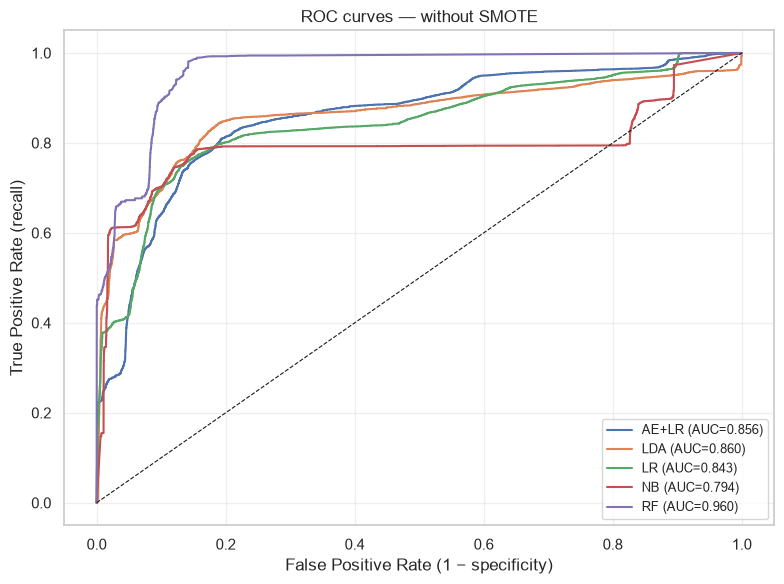

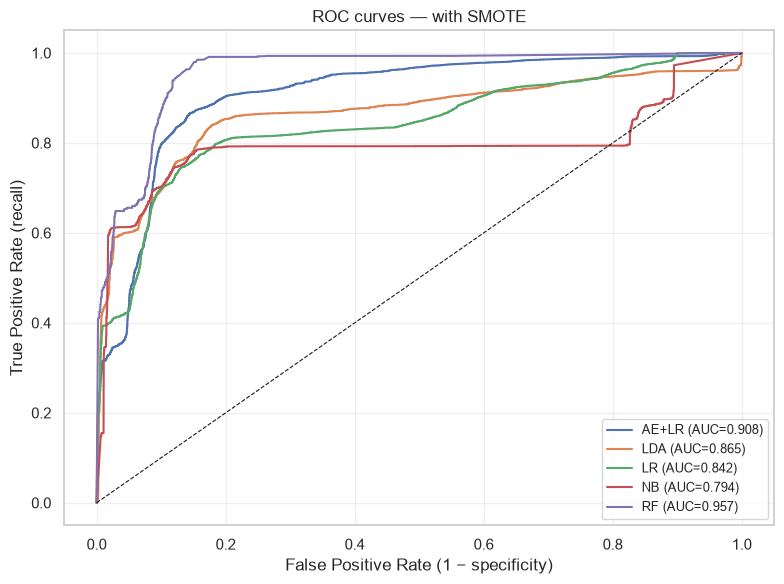

In [17]:
for smote_flag, title in [(False, 'Without SMOTE'), (True, 'With SMOTE')]:
    fig = plot_roc_curves(predictions, smote=smote_flag)
    out = EVAL_FIG_DIR / f"roc_{'smote' if smote_flag else 'no_smote'}.png"
    fig.savefig(out, dpi=120)
    plt.show()
    plt.close(fig)


### 5.3 Evaluation conclusions

- **NB** maximizes precision (~0.97) but misses most attacks (recall ~0.15) — a conservative detector unsuitable when missed intrusions are costly.
- **RF** achieves the highest AUC (~0.96) with moderate FAR — strong ranking of attack vs normal traffic.
- **LDA/LR** offer balanced precision–recall; SMOTE yields modest recall gains at slightly higher FAR.
- **AE+LR** does not dominate AUC in our pipeline (unlike the paper's cleaned-CSV baseline), supporting a critical review of claim C1.


## 6. Error analysis

We decompose failures by attack family (DoS, Probe, R2L, U2R) and inspect rare **R2L** (remote-to-local) and **U2R** (user-to-root) attacks — historically the hardest classes in KDD-derived benchmarks.


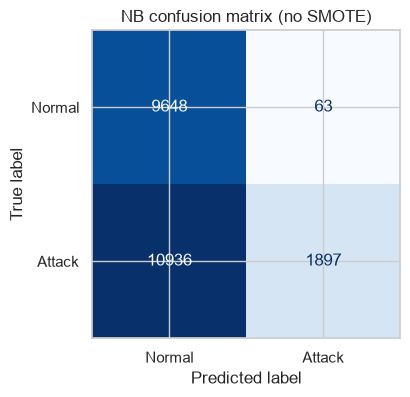

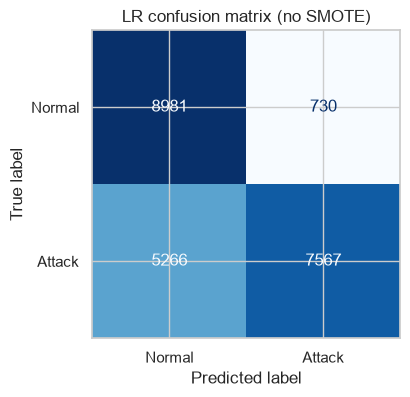

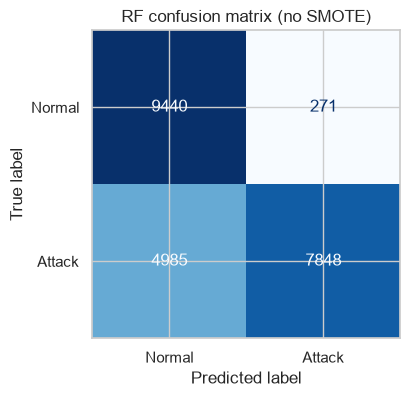

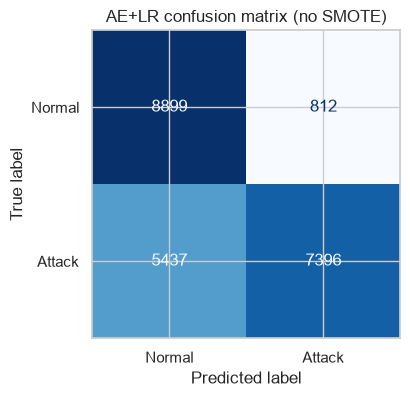

In [18]:
from src.evaluation import (
    compare_model_errors,
    error_by_attack_family,
    error_by_attack_label,
    false_positive_summary,
    plot_confusion_matrix,
    plot_threshold_tradeoff,
    threshold_sweep,
)

# Confusion matrices for key models (no SMOTE)
for model in ['NB', 'LR', 'RF', 'AE+LR']:
    preds = predictions[(model, False)]
    plot_confusion_matrix(
        preds['y_true'], preds['y_pred'],
        title=f'{model} confusion matrix (no SMOTE)',
    )
    plt.savefig(EVAL_FIG_DIR / f'cm_{model.replace("+", "_")}_no_smote.png', dpi=120)
    plt.show()
    plt.close()


### 6.1 False positives vs false negatives


,model,false_positives,false_negatives
0,AE+LR,812,5437
1,LDA,667,4704
2,LR,730,5266
3,NB,63,10936
4,RF,271,4985


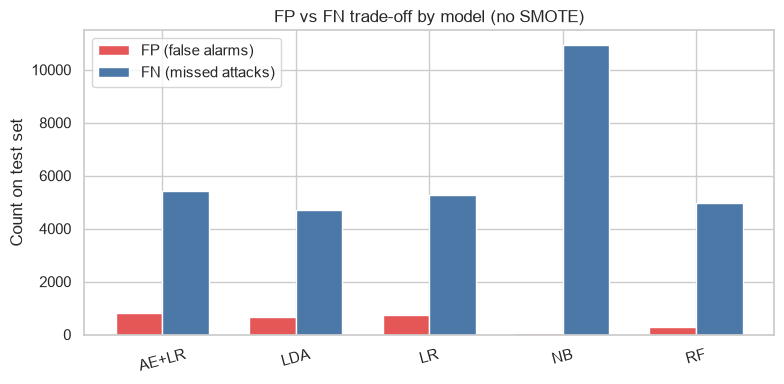

In [19]:
error_counts = compare_model_errors(test_df, predictions, smote=False)
display(error_counts)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(error_counts))
width = 0.35
ax.bar([i - width/2 for i in x], error_counts['false_positives'], width, label='FP (false alarms)', color='#e45756')
ax.bar([i + width/2 for i in x], error_counts['false_negatives'], width, label='FN (missed attacks)', color='#4c78a8')
ax.set_xticks(list(x))
ax.set_xticklabels(error_counts['model'], rotation=15)
ax.set_ylabel('Count on test set')
ax.set_title('FP vs FN trade-off by model (no SMOTE)')
ax.legend()
plt.tight_layout()
plt.savefig(EVAL_FIG_DIR / 'fp_fn_tradeoff.png', dpi=120)
plt.show()


### 6.2 Detection by attack family (RF, no SMOTE)


,attack_family,attacks_in_test,detected,missed_fn,recall
0,DOS,7458,5938,1520,0.7962
1,PROBE,2421,1676,745,0.6923
2,R2L,2887,227,2660,0.0786
3,U2R,67,7,60,0.1045


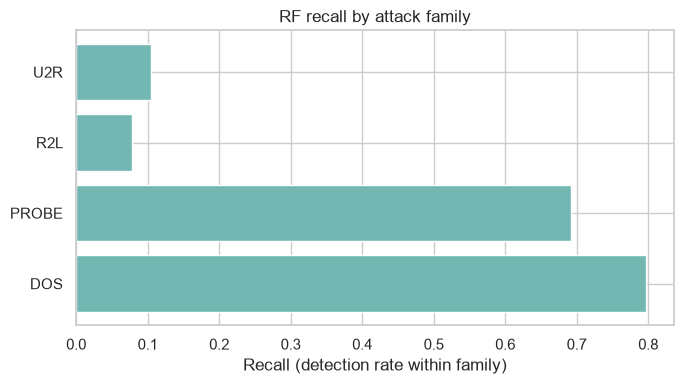

In [20]:
rf_preds = predictions[('RF', False)]
family_errors = error_by_attack_family(test_df, rf_preds['y_pred'])
display(family_errors)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(family_errors['attack_family'], family_errors['recall'], color='#72b7b2')
ax.set_xlabel('Recall (detection rate within family)')
ax.set_title('RF recall by attack family')
plt.tight_layout()
plt.savefig(EVAL_FIG_DIR / 'rf_recall_by_family.png', dpi=120)
plt.show()


### 6.3 Rare attacks — R2L and U2R (LR, no SMOTE)

These subclasses have few test examples; per-label recall is unstable but exposes which stealthy patterns the linear model misses entirely.


In [21]:
lr_preds = predictions[('LR', False)]
rare_errors = error_by_attack_label(test_df, lr_preds['y_pred'])
display(rare_errors)

fp_lr = false_positive_summary(test_df, lr_preds['y_pred'])
print('LR false-positive summary:', fp_lr)


,label,family,count,detected,missed,recall
3,httptunnel,R2L,133,0,133,0.0000
9,phf,R2L,2,0,2,0.0000
12,sendmail,R2L,14,0,14,0.0000
17,worm,R2L,2,0,2,0.0000
18,xlock,R2L,9,0,9,0.0000
19,xsnoop,R2L,4,0,4,0.0000
2,guess_passwd,R2L,1231,1,1230,0.0008
13,snmpgetattack,R2L,178,1,177,0.0056
14,snmpguess,R2L,331,2,329,0.0060
16,warezmaster,R2L,944,18,926,0.0191


LR false-positive summary: {'false_positives': 730, 'true_negatives': 8981, 'far': 0.0752}


### 6.4 Threshold discussion

Default classifiers use a **0.5 probability threshold**. SOC operators often lower the threshold to increase recall (catch more attacks) at the cost of FAR. Below we sweep LR thresholds to illustrate this trade-off.


,threshold,precision,recall,f1,far
0,0.05,0.8753,0.7610,0.8142,0.1432
1,0.10,0.8974,0.7079,0.7914,0.1070
2,0.15,0.9060,0.6951,0.7866,0.0954
3,0.20,0.9087,0.6843,0.7807,0.0908
4,0.25,0.9097,0.6676,0.7701,0.0875
5,0.30,0.9106,0.6470,0.7565,0.0839
6,0.35,0.9110,0.6267,0.7426,0.0809
7,0.40,0.9108,0.6121,0.7322,0.0792
8,0.45,0.9115,0.6012,0.7245,0.0771
9,0.50,0.9120,0.5897,0.7162,0.0752


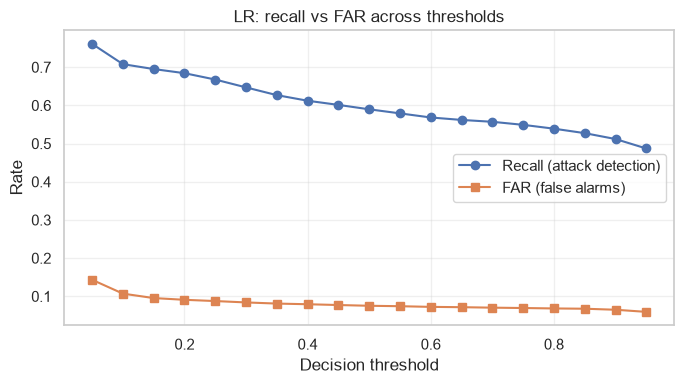

In [22]:
sweep = threshold_sweep(lr_preds['y_true'], lr_preds['y_proba'])
display(sweep.round(4))

fig = plot_threshold_tradeoff(sweep, title='LR: recall vs FAR across thresholds')
fig.savefig(EVAL_FIG_DIR / 'threshold_tradeoff_LR.png', dpi=120)
plt.show()
plt.close(fig)


### 6.5 Error analysis conclusions

- **DoS/Probe** attacks are detected reliably (high within-family recall); errors concentrate on **R2L/U2R** where training examples are scarce.
- **NB** minimizes false alarms but leaves ~85% of attacks undetected — unacceptable when recall is prioritized.
- **RF** reduces FN relative to LR while keeping FAR lower than AE+LR in our runs.
- Lowering the LR threshold below 0.5 can boost recall on rare classes but will increase analyst workload — deployment requires environment-specific tuning, not a fixed 0.5 cut-off.


## 7. Critical evaluation

We synthesize reproduction evidence against the seven author claims (C1–C7) defined in `prd.md`, using `results/baseline_reproduction.csv` (author pipeline), `results/experiment_metrics.csv` (our pipeline), and audits in `docs/reproducibility_notes.md`. The full matrix lives in `docs/critical_evaluation.md`.

### 7.1 Claim verdicts

| Claim | Summary | Verdict |
|-------|---------|---------|
| **C1** — AE+LR best AUC (~0.904) and F1 | Author baseline: AE+LR AUC 0.904, F1 0.753 (top among four). Our pipeline: RF AUC 0.960, LDA F1 0.752; AE+LR below both. | **Partially supported** |
| **C2** — SMOTE modest F1 gains | Author ΔF1: +0.003 LR, +0.002 LDA, +0.005 AE+LR. Ours: up to +0.031 AE+LR; always train-only. | **Supported** |
| **C3** — Leakage-free preprocessing | Author: concat train+test before one-hot. Ours: fit encoders/scalers on train only. | **Rejected (author) / Supported (ours)** |
| **C4** — LR/LDA strong baselines | LDA F1 within 0.002 of AE+LR in author runs; same in ours. LR slightly lower but competitive. | **Supported** |
| **C5** — NB high Prec, low Rec | Prec ~0.97–0.98, Rec ~0.15–0.24, FAR 0.65%; 10,936 FN vs 63 FP (our NB). | **Supported** |
| **C6** — FAR essential for IDS | NB accuracy 0.51 with low FAR but blind to attacks; threshold sweeps show hidden recall/FAR trade-offs. | **Supported** |
| **C7** — Byte-level reproducibility | All Table 4/5 metrics matched; hidden CSV ETL and library drift prevent raw-data byte identity. | **Partially supported** |

### 7.2 Methodology critique

**Weaknesses**

- Binary labels hide catastrophic R2L/U2R failure (e.g., `guess_passwd`, `snmpguess` at 0% recall under LR).
- NSL-KDD is legacy; near-ceiling DoS/Probe metrics lack external validity for modern networks.
- Accuracy (~0.75–0.77 for top models) masks ~5,000 missed attacks per model on the test set.
- Author replication depends on undocumented cleaned CSVs and joint encoding that risks schema leakage.

**Strengths**

- FAR included alongside standard metrics — operationally meaningful for SOC staffing.
- Fixed seeds and public code enabled independent verification (we matched all reported NSL-KDD numbers).
- Train-only SMOTE and official KDDTrain+/KDDTest+ split follow sound experimental protocol when implemented correctly.

### 7.3 Conclusions and recommendation

The authors deliver a **reproducible classical-ML benchmark** with thoughtful metric reporting, but several headline claims **do not survive strict preprocessing** or **multiclass scrutiny**. LDA provides equivalent F1 to AE+LR at a fraction of training cost; Random Forest (our extension) dominates AUC. SMOTE helps modestly but does not fix rare-attack detection.

**Recommendation:** Adopt the paper's metric framework (especially FAR and fixed seeds) for similar tabular IDS benchmarks. Do **not** treat AE+LR superiority or near-0.90 AUC as evidence of deployable detection without per-family evaluation on contemporary data.

### 7.4 Report-ready findings

- Reproduced all author NSL-KDD metrics within tolerance; replication package works with bundled CSVs.
- AE+LR leads only in author pipeline; LDA/RF competitive or superior under train-only encoding.
- SMOTE: modest aggregate F1 gains; R2L recall remains ~8%, U2R ~10%.
- NB: precision-first profile unsuitable as standalone detector (FAR 0.65%, recall ~15%).
- Author train+test concat encoding contradicts leakage-free claim — audit before trusting results.
- FAR and MCC required alongside accuracy for meaningful SOC comparison.
